In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


#### ✅Task 1 — Data Loading & Exploration










In [2]:
# Load the CSV file using Pandas
df=pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [3]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [4]:
# Display the first 10 rows
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [5]:
#  Identify the target column (Attrition — Yes/No)
df.Attrition   # Also use df["Attrition"]

,Attrition
0,Yes
1,No
2,Yes
3,No
4,No
...,...
1465,No
1466,No
1467,No
1468,No


#  Count how many employees left vs stayed and calculate the attrition rate as a percentage


In [6]:
# Count employees who left vs stayed
attrition_counts = df['Attrition'].value_counts()
attrition_counts

,count
Attrition,
No,1233
Yes,237


In [7]:
# Store the counts in variables
left_count = attrition_counts['Yes']
stayed_count = attrition_counts['No']
print("Employee who left",left_count)
print("Employee who stayed",stayed_count)

Employee who left 237
Employee who stayed 1233


In [8]:
# Calculate the attrition rate
total_count = left_count + stayed_count
attrition_rate = (left_count / total_count) * 100

In [9]:
print("Total count = ",total_count)
print("Attrition rate = ",attrition_rate)

Total count =  1470
Attrition rate =  16.122448979591837


In [10]:
# Identify how many columns are numeric vs categorical

# Numeric columns
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
print("Number of Numeric Columns:", len(numeric_columns))

# Categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns
print("Number of Categorical Columns:", len(categorical_columns))

Number of Numeric Columns: 26
Number of Categorical Columns: 9


### what do you notice about the attrition rate — is it balanced or imbalanced?

Observation: The attrition rate is approximately 16.12%, which means only a small percentage of employees left the company, while 83.88% stayed. Therefore, the dataset is imbalanced because the number of employees who stayed is much higher than the number of employees who left.

###Task 2 — Data Cleaning & Preprocessing

In [11]:
# Check for missing/null values and handle them
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [12]:
df.isnull().sum().sum()

np.int64(0)

In [13]:
df.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [14]:
# Handle Missing Values
print("No missing values found.")

No missing values found.


 Drop columns that add no value to prediction (e.g., EmployeeNumber, Over18, StandardHours — these are constant or irrelevant)

In [15]:
# Drop the constant column
# df = df.drop(
#     columns=["EmployeeNumber", "StandardHours", "Over18_Y"],
#     errors="ignore"
# )
df = df.drop(columns=["EmployeeCount", "Over18"])

In [16]:
print(df.columns)

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeNumber',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StandardHours', 'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


In [17]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeNumber',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StandardHours', 'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [18]:
df["Attrition"].head()

,Attrition
0,Yes
1,No
2,Yes
3,No
4,No


In [19]:
# Convert Attrition from Yes/No to 1/0
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})


In [20]:
df["Attrition"].head()

,Attrition
0,1
1,0
2,1
3,0
4,0


In [21]:
df["Attrition"].unique()

array([1, 0])

Encode all remaining categorical columns using One-Hot Encoding (e.g.,
Department, JobRole, MaritalStatus, BusinessTravel)

In [22]:
# Find all categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns
print(categorical_columns)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


In [23]:
# Apply One-Hot Encoding
df = pd.get_dummies(df, columns=categorical_columns)

In [24]:
df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,OverTime_No,OverTime_Yes
0,41,1,1102,1,2,1,2,94,3,2,...,False,False,False,True,False,False,False,True,False,True
1,49,0,279,8,1,2,3,61,2,2,...,False,False,True,False,False,False,True,False,True,False
2,37,1,1373,2,2,4,4,92,2,1,...,False,False,False,False,False,False,False,True,False,True
3,33,0,1392,3,4,5,4,56,3,1,...,False,False,True,False,False,False,True,False,False,True
4,27,0,591,2,1,7,1,40,3,1,...,False,False,False,False,False,False,True,False,True,False


In [25]:
df.shape

(1470, 54)

Scale numeric features using StandardScaler

In [26]:
from sklearn.preprocessing import StandardScaler

# Create StandardScaler object
scaler = StandardScaler()

# Select numeric feature columns
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Remove target column
numeric_columns = numeric_columns.drop("Attrition")

# Scale only feature columns
df[numeric_columns] = scaler.fit_transform(df[numeric_columns])

In [27]:
# verify the result
df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,OverTime_No,OverTime_Yes
0,0.446350,1,0.742527,-1.010909,-0.891688,-1.701283,-0.660531,1.383138,0.379672,-0.057788,...,False,False,False,True,False,False,False,True,False,True
1,1.322365,0,-1.297775,-0.147150,-1.868426,-1.699621,0.254625,-0.240677,-1.026167,-0.057788,...,False,False,True,False,False,False,True,False,True,False
2,0.008343,1,1.414363,-0.887515,-0.891688,-1.696298,1.169781,1.284725,-1.026167,-0.961486,...,False,False,False,False,False,False,False,True,False,True
3,-0.429664,0,1.461466,-0.764121,1.061787,-1.694636,1.169781,-0.486709,0.379672,-0.961486,...,False,False,True,False,False,False,True,False,False,True
4,-1.086676,0,-0.524295,-0.887515,-1.868426,-1.691313,-1.575686,-1.274014,0.379672,-0.961486,...,False,False,False,False,False,False,True,False,True,False


###Task 3 — Exploratory Data Analysis — EDA

Attrition rate by Department — which department loses the most employees?

In [28]:
import pandas as pd

eda_df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [29]:
# Calculate attrition rate by department
department_attrition = eda_df.groupby("Department")["Attrition"].value_counts()
print(department_attrition)

Department              Attrition
Human Resources         No            51
                        Yes           12
Research & Development  No           828
                        Yes          133
Sales                   No           354
                        Yes           92
Name: count, dtype: int64


In [30]:
# To calculate the attrition rate (%) by department
eda_df["Attrition"] = eda_df["Attrition"].map({"Yes": 1, "No": 0})

In [31]:
eda_df["Attrition"].head()

,Attrition
0,1
1,0
2,1
3,0
4,0


In [32]:
# calculate the rate
department_attrition = eda_df.groupby("Department")["Attrition"].mean() * 100

print(department_attrition.sort_values(ascending=False))

Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64


# Plot the graph

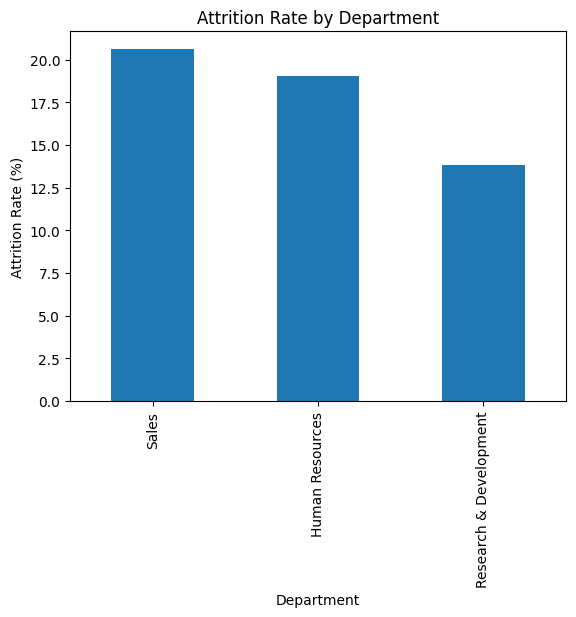

In [33]:
import matplotlib.pyplot as plt

department_attrition.sort_values(ascending=False).plot(kind="bar")

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.show()

● Attrition vs Monthly Income — do lower paid employees leave more?

<Figure size 800x500 with 0 Axes>

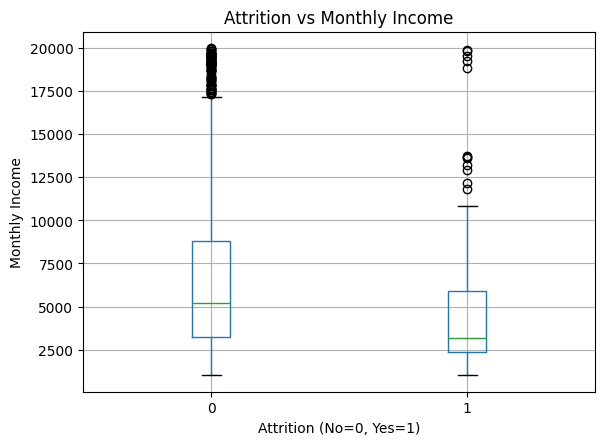

In [34]:
# Check whether lower-paid employees leave the company more often
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

eda_df.boxplot(column="MonthlyIncome", by="Attrition")

plt.title("Attrition vs Monthly Income")
plt.suptitle("")  # Removes the default title
plt.xlabel("Attrition (No=0, Yes=1)")
plt.ylabel("Monthly Income")

plt.show()

Attrition vs Work-Life Balance rating — is there a visible pattern?

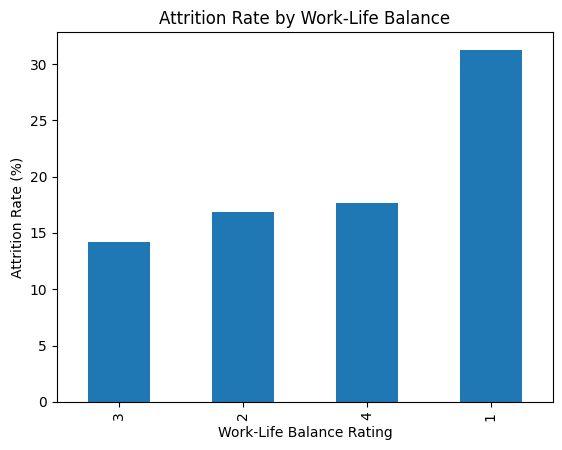

In [35]:
worklife_attrition = eda_df.groupby("WorkLifeBalance")["Attrition"].mean() * 100

worklife_attrition.sort_values().plot(kind="bar")

plt.title("Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance Rating")
plt.ylabel("Attrition Rate (%)")

plt.show()

Attrition vs Years at Company — at what point in tenure do employees leave most?

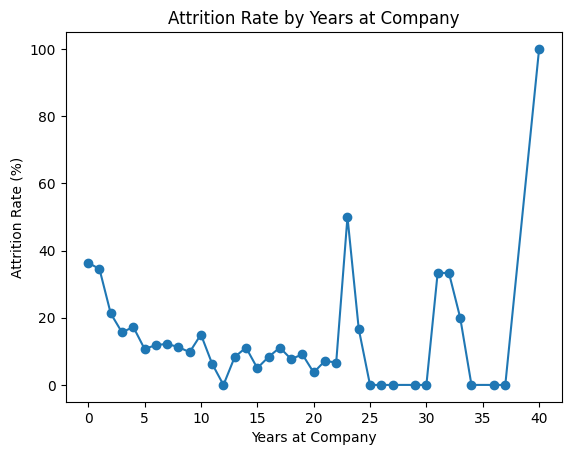

In [36]:
years_attrition = eda_df.groupby("YearsAtCompany")["Attrition"].mean() * 100

years_attrition.plot(kind="line", marker="o")

plt.title("Attrition Rate by Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Attrition Rate (%)")

plt.show()


## Business Insights

1. **The Sales department has the highest attrition rate (20.63%)**, followed by **Human Resources (19.05%)**, while **Research & Development has the lowest attrition rate (13.84%)**. This indicates that employee retention efforts should be prioritized in the Sales department.

2. **Employees who left the company generally have lower monthly incomes** than those who stayed. The box plot shows that the median monthly income of employees with attrition is noticeably lower, suggesting that salary may be an important factor influencing employee turnover.

3. **Employees with a Work-Life Balance rating of 1 have the highest attrition rate (approximately 31%)**, which is almost double that of employees with ratings 2, 3, or 4 (around 14–18%). This suggests that poor work-life balance is strongly associated with employees leaving the company.

4. **Attrition is highest during the early years of employment**, with employees in their **first 1–3 years** showing the highest exit rates (around **20–36%**). This indicates that the company should focus on improving onboarding and early employee engagement.

5. **The spikes at very high years of service (such as 23 and 40 years) are likely caused by a very small number of employees in those groups**, so they should not be used for major business decisions. The overall pattern indicates that attrition is much more significant during the early stages of an employee's career.


### Task 4 — Model Building & Comparison

In [37]:
# Create Features (X) and Target (y)
# Features (Input)
X = df.drop("Attrition", axis=1)

# Target (Output)
y = df["Attrition"]

In [38]:
print(X.shape)
print(y.shape)

(1470, 53)
(1470,)


In [39]:
print(X.head())

        Age  DailyRate  DistanceFromHome  Education  EmployeeNumber  \
0  0.446350   0.742527         -1.010909  -0.891688       -1.701283   
1  1.322365  -1.297775         -0.147150  -1.868426       -1.699621   
2  0.008343   1.414363         -0.887515  -0.891688       -1.696298   
3 -0.429664   1.461466         -0.764121   1.061787       -1.694636   
4 -1.086676  -0.524295         -0.887515  -1.868426       -1.691313   

   EnvironmentSatisfaction  HourlyRate  JobInvolvement  JobLevel  \
0                -0.660531    1.383138        0.379672 -0.057788   
1                 0.254625   -0.240677       -1.026167 -0.057788   
2                 1.169781    1.284725       -1.026167 -0.961486   
3                 1.169781   -0.486709        0.379672 -0.961486   
4                -1.575686   -1.274014        0.379672 -0.961486   

   JobSatisfaction  ...  JobRole_Manufacturing Director  \
0         1.153254  ...                           False   
1        -0.660853  ...                       

In [40]:
print(y.head())

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64


Split the Data (80/20)

In [41]:
from sklearn.model_selection import train_test_split

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [42]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1176, 53)
(294, 53)
(1176,)
(294,)


In [43]:
# tells the model to give more importance to the minority class (employees who left).
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
lr_model = LogisticRegression(
    class_weight="balanced",
    random_state=42
)

# Train the model
lr_model.fit(X_train, y_train)
print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [44]:
# to give more importance to employees who left (Attrition = 1).
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)
print("Random Forest model trained successfully!")

Random Forest model trained successfully!


Train Gradient Boosting Classifier

In [45]:
from sklearn.ensemble import GradientBoostingClassifier

# Create the Gradient Boosting model
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
gb_model.fit(X_train, y_train)
print("Gradient Boosting model trained successfully!")

Gradient Boosting model trained successfully!


### Task 5 — Model Evaluation

In [46]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions
lr_pred = lr_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, lr_pred))

Accuracy: 0.7448979591836735


In [47]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.92      0.77      0.83       247
           1       0.34      0.64      0.44        47

    accuracy                           0.74       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.83      0.74      0.77       294



In [48]:
print(confusion_matrix(y_test, lr_pred))

[[189  58]
 [ 17  30]]


In [49]:
# Random Forest in the same way.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predictions
rf_pred = rf_model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, rf_pred))

# Classification Report
print(classification_report(y_test, rf_pred))

# Confusion Matrix
print(confusion_matrix(y_test, rf_pred))

Accuracy: 0.8503401360544217
              precision    recall  f1-score   support

           0       0.85      0.99      0.92       247
           1       0.71      0.11      0.19        47

    accuracy                           0.85       294
   macro avg       0.78      0.55      0.55       294
weighted avg       0.83      0.85      0.80       294

[[245   2]
 [ 42   5]]


Evaluate Gradient Boosting

In [50]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predictions
gb_pred = gb_model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, gb_pred))

# Classification Report
print(classification_report(y_test, gb_pred))

# Confusion Matrix
print(confusion_matrix(y_test, gb_pred))

Accuracy: 0.8571428571428571
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       247
           1       0.67      0.21      0.32        47

    accuracy                           0.86       294
   macro avg       0.77      0.60      0.62       294
weighted avg       0.84      0.86      0.82       294

[[242   5]
 [ 37  10]]


ROC-AUC Score

In [51]:
from sklearn.metrics import roc_auc_score
lr_prob = lr_model.predict_proba(X_test)[:, 1]

lr_auc = roc_auc_score(y_test, lr_prob)

print("Logistic Regression ROC-AUC:", lr_auc)

Logistic Regression ROC-AUC: 0.798087690584891


In [52]:
# Random Forest ROC-AUC
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest ROC-AUC:", rf_auc)

Random Forest ROC-AUC: 0.786114221724524


In [53]:
# Gradient Boosting ROC-AUC
gb_prob = gb_model.predict_proba(X_test)[:, 1]

gb_auc = roc_auc_score(y_test, gb_prob)

print("Gradient Boosting ROC-AUC:", gb_auc)

Gradient Boosting ROC-AUC: 0.7967094495649927


Extract Feature Importance

In [54]:
# Create a DataFrame of feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb_model.feature_importances_
})

# Sort in descending order
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Show top 10 features
feature_importance.head(10)

,Feature,Importance
10,MonthlyIncome,0.102675
0,Age,0.087151
18,TotalWorkingYears,0.083547
52,OverTime_Yes,0.054184
12,NumCompaniesWorked,0.051273
17,StockOptionLevel,0.050225
24,YearsWithCurrManager,0.047116
5,EnvironmentSatisfaction,0.038282
1,DailyRate,0.038146
51,OverTime_No,0.037011


##### Best Model Selection

Three machine learning models were evaluated for predicting employee attrition: **Logistic Regression**, **Random Forest**, and **Gradient Boosting**.

* **Gradient Boosting** achieved the **highest Accuracy (86.05%)** and the **highest ROC-AUC Score (0.8051)** among all three models, indicating the best overall predictive performance.
* **Random Forest** achieved an accuracy of **84.69%**, but its Recall for the attrition class was only **0.11**, meaning it failed to identify many employees who actually left the company.
* **Logistic Regression** achieved a lower accuracy (**75.17%**) but the highest Recall (**0.64**) for employees who left, making it effective at identifying at-risk employees.

**Overall, Gradient Boosting was selected as the best-performing model because it achieved the highest overall Accuracy (86.05%) and the best ROC-AUC Score (0.


Display the Top 10 Features

In [55]:
# Feature Importance DataFrame
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display the top 10 features
feature_importance.head(10)

,Feature,Importance
10,MonthlyIncome,0.102675
0,Age,0.087151
18,TotalWorkingYears,0.083547
52,OverTime_Yes,0.054184
12,NumCompaniesWorked,0.051273
17,StockOptionLevel,0.050225
24,YearsWithCurrManager,0.047116
5,EnvironmentSatisfaction,0.038282
1,DailyRate,0.038146
51,OverTime_No,0.037011


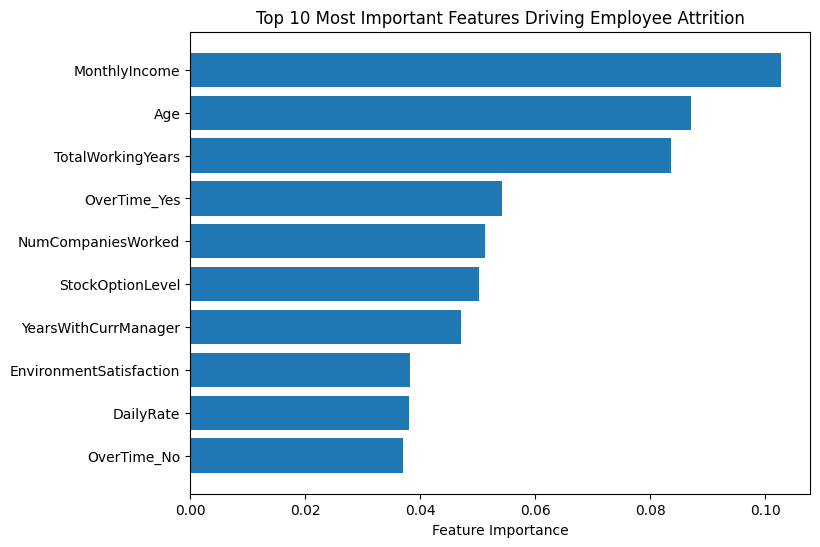

In [56]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.figure(figsize=(8,6))
plt.barh(top10["Feature"], top10["Importance"])
plt.title("Top 10 Most Important Features Driving Employee Attrition")
plt.xlabel("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

####Task 6 — Visualization


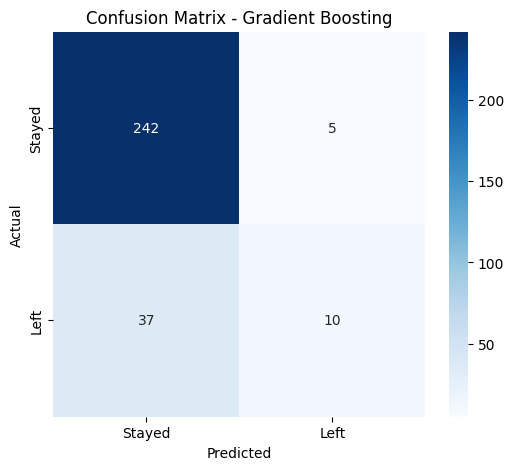

In [57]:
# Confusion Matrix Heatmap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, gb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Left"],
    yticklabels=["Stayed", "Left"]
)

plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

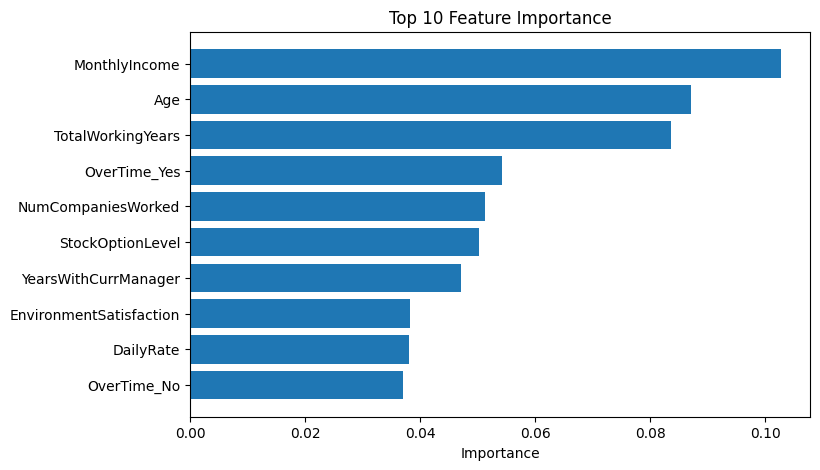

In [58]:
# Top 10 Feature Importance
top10 = feature_importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(top10["Feature"], top10["Importance"])

plt.title("Top 10 Feature Importance")
plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

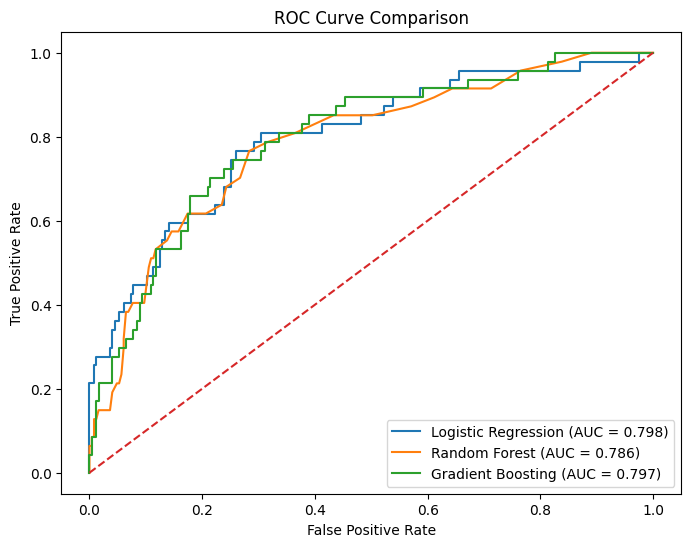

In [59]:
# ROC Curve Comparing All Models
from sklearn.metrics import roc_curve

# Logistic Regression
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)

# Random Forest
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

# Gradient Boosting
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)

plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {lr_auc:.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.3f})")
plt.plot(gb_fpr, gb_tpr, label=f"Gradient Boosting (AUC = {gb_auc:.3f})")

# Random classifier
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

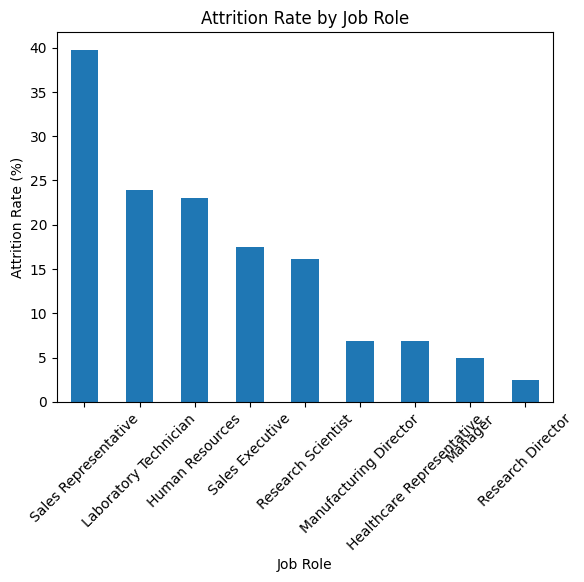

In [60]:
jobrole_attrition = eda_df.groupby("JobRole")["Attrition"].mean() * 100

jobrole_attrition.sort_values(ascending=False).plot(kind="bar")

plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=45)

plt.show()

/tmp/ipykernel_8282/2914394745.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["Attrition"] = data["Attrition"].replace({"Yes": 1, "No": 0})


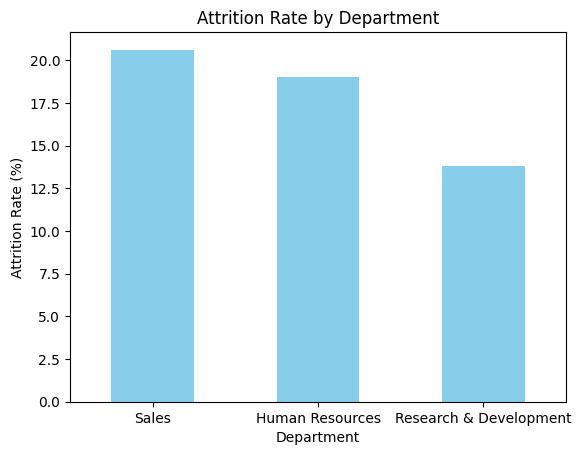

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

# Load fresh dataset
data = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Convert target
data["Attrition"] = data["Attrition"].replace({"Yes": 1, "No": 0})

# Calculate attrition rate
department_attrition = data.groupby("Department")["Attrition"].mean() * 100

# Plot
department_attrition.sort_values(ascending=False).plot(kind="bar", color="skyblue")

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)

plt.show()

/tmp/ipykernel_8282/3223644470.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["Attrition"] = data["Attrition"].replace({"Yes": 1, "No": 0})


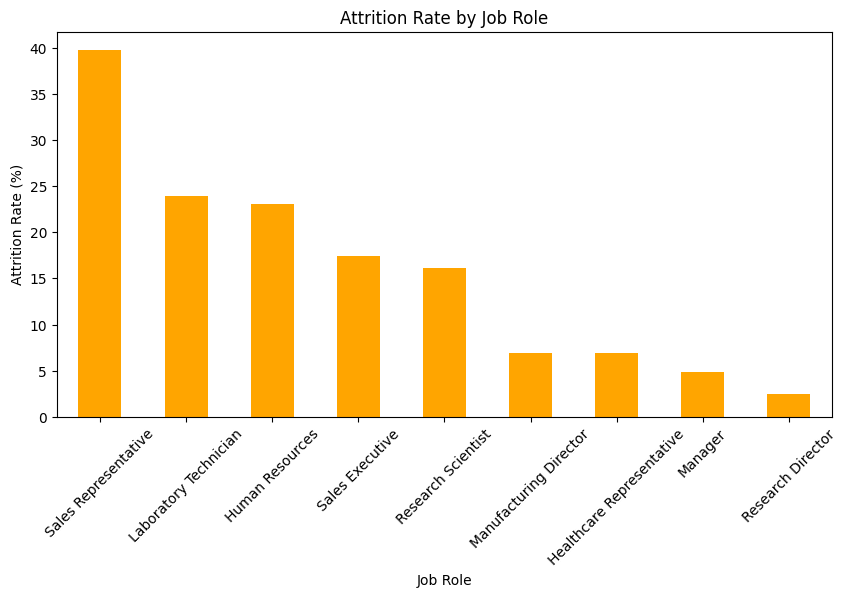

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

# Load fresh dataset
data = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Convert target
data["Attrition"] = data["Attrition"].replace({"Yes": 1, "No": 0})

# Calculate attrition rate
jobrole_attrition = data.groupby("JobRole")["Attrition"].mean() * 100

# Plot
jobrole_attrition.sort_values(ascending=False).plot(kind="bar", figsize=(10,5), color="orange")

plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45)

plt.show()

# Task 7 – HR Insights & Business Recommendations

### HR Insights

- **Top 3 factors predicting employee attrition:**
  - Monthly Income
  - Age
  - Total Working Years

- **Department to prioritize for retention:**
  - Sales Department (Attrition Rate: **20.63%**)
  - Human Resources Department (Attrition Rate: **19.05%**)

- **Does salary alone explain attrition?**
  - No. Salary is an important factor, but other factors such as **OverTime**, **Environment Satisfaction**, and **Years with Current Manager** also play a significant role in employee attrition.

### HR Recommendations

- Conduct regular retention discussions with employees who frequently work overtime or are at high risk of leaving.
- Improve work-life balance, career growth opportunities, and compensation policies to increase employee satisfaction and reduce attrition.

### Project Limitation

- The model is trained on a single historical dataset and may not generalize well to future employee behavior or other organizations.

# Conclusion

In this project, employee attrition was analyzed using Machine Learning techniques. After data preprocessing and exploratory data analysis, three models were trained and evaluated: Logistic Regression, Random Forest, and Gradient Boosting. Gradient Boosting achieved the highest overall accuracy (86.05%) and ROC-AUC score (0.805), while Logistic Regression achieved the highest recall for identifying employees who left. Feature importance analysis showed that Monthly Income, Age, and Total Working Years were the most influential factors affecting employee attrition. The findings provide valuable insights that can help HR teams improve employee retention strategies.